# Week 1 · Notebook 3 — From signal to strategy, and the heart of the engine

Yesterday you built indicators on real prices. Today you turn one into a
**strategy** — a rule that decides how to hold money across many stocks at once —
and you write the single most important function in the whole program: the one
that turns holdings into a return.

Two functions you build:
1. `sma_crossover_weights` — a real trading strategy, working across the whole
   universe at once (trend-following).
2. `portfolio_return` — the heart of the engine. Every backtest, and next week's
   RL agent, runs through it.

## 1. First, on real prices — no shortcuts

Before wiring anything into the engine, build the intuition on real numbers you can
see. Load one stock's actual closing prices and look at the two averages side by
side.

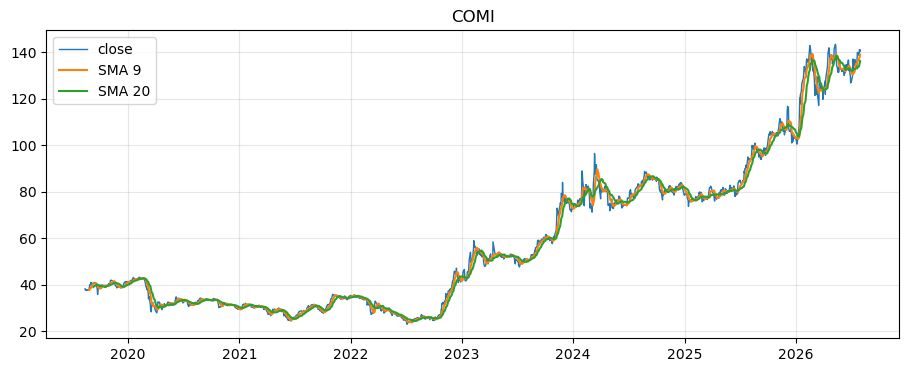

today: fast = 139.09 | slow = 136.25
fast > slow -> uptrend (hold)


In [1]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np
import matplotlib.pyplot as plt
from tradinglab.data_feed import DataFeed
from tradinglab.indicators import sma          # your graduated function from NB2

# feed = DataFeed.from_dir('data/egx')

feed = DataFeed.from_dir('data/egx', symbols=['COMI', 'HRHO', 'TMGH', 'SWDY', 'FWRY', 'ABUK'])

prices = feed.close[:, 0]                      # real closing prices, first stock

fast_avg = sma(prices, 9)
slow_avg = sma(prices, 20)

plt.figure(figsize=(11, 4))
plt.plot(feed.dates, prices, label='close', linewidth=1.0)
plt.plot(feed.dates, fast_avg, label='SMA 9')
plt.plot(feed.dates, slow_avg, label='SMA 20')
plt.legend(); plt.grid(alpha=0.3); plt.title(feed.symbols[0])
plt.show()

print('today: fast =', round(fast_avg[-1], 2), '| slow =', round(slow_avg[-1], 2))
print('fast > slow ->', 'uptrend (hold)' if fast_avg[-1] > slow_avg[-1] else 'no trend (cash)')

## 2. The environment, part two: how money actually moves

Now the machine this strategy has to feed. A strategy's job is to output
**weights** — what fraction of your money sits in each stock (they sum to 1) —
for the *whole universe at once*, not just one stock. The **simulator** then asks
the only question that matters:

> You hold these weights today. Each stock earns some return tomorrow. What does
> your *portfolio* earn?

The simulator loops that one step across history to build an equity curve. It
holds no strategy logic — just this accounting. If you understand
`portfolio_return`, you understand the engine.

**One catch:** the simulator only ever hands a strategy an `observation` — a
window shaped `(n_assets, lookback, n_features)` — never raw prices directly. So
before you write the real strategy function, you need to know what's inside that
window.

## 3. Why the window stores *returns*, not price — and why that's fine

Feature 0 of the observation is each stock's **daily return**, not its price. That
sounds like it should be a problem — didn't we just build the crossover on real
*prices* above? Two things make it not a problem:

**Why returns, not price:** the observation is one shared tensor covering every
stock in the universe, and they trade at wildly different price levels (one stock
might sit near 2 EGP, another near 130 EGP). If the tensor stored raw price, every
model or agent that reads it would have to deal with those mismatched scales.
Returns are already scale-free and directly comparable across stocks — that's the
whole reason the contract is built this way.

**Why the crossover still works on returns:** compounding a stock's returns
forward from 1.0 — `np.cumprod(1 + returns)` — gives you the *exact* price path,
just rescaled by a constant (starting at 1.0 instead of the real starting price).
SMA is linear, so scaling every price by the same constant scales `SMA_fast` and
`SMA_slow` by that same constant too — meaning **the comparison `SMA_fast >
SMA_slow` gives the identical true/false answer**, whether you use real prices or
this rescaled version. Nothing is faked; it's an exact shortcut, not a
workaround.

In [2]:
# proof, not just a claim: same signal, real price vs. the rescaled version
real_signal  = sma(prices, 9)[-1] > sma(prices, 20)[-1]
rescaled     = np.cumprod(1 + feed.returns[:, 0])
rescaled_signal = sma(rescaled, 9)[-1] > sma(rescaled, 20)[-1]
print('signal from real prices    :', real_signal)
print('signal from rescaled returns:', rescaled_signal)
print('identical ✓' if real_signal == rescaled_signal else 'MISMATCH — investigate')

signal from real prices    : True
signal from rescaled returns: True
identical ✓


## 4. Function — `sma_crossover_weights` (multi-asset, for real)

Now the real strategy. It must work across **every** stock in the universe at
once, because that's what the engine expects: one weights vector covering the
whole portfolio.

**Rule, in plain words, for each stock:**
- Rebuild its price path from the observation's returns.
- If there isn't enough history yet, skip it (stay out).
- Compute the fast and slow averages.
- If the fast average is above the slow average, hold it.
- Split the money equally across every stock that qualifies. If none qualify,
  hold nothing — genuine cash, not a forced equal-weight bet. The same
  principle as the predictor you'll build in week 2: don't buy something just
  because a decision has to be made.

**In:** `observation` shape `(n_assets, lookback, n_features)`, feature 0 = returns.
**Out:** `weights` shape `(n_assets,)`, non-negative, summing to 1.
**Done when:** the check passes.


In [3]:
def sma_crossover_weights(observation, fast=9, slow=20):
    """Hold when the fast average price is above the slow average price.

    If NOTHING qualifies as an uptrend, hold nothing (cash) — same principle as
    the predictor from week 2: don't force a bet just because something has to
    be picked. An empty portfolio some days is honest; a forced equal-weight
    bet on stocks that aren't actually trending up is not.
    """
    n_assets = observation.shape[0]
    lookback = observation.shape[1]

    # Start by assuming we hold nothing.
    hold = np.zeros(n_assets)

    # Check each stock one at a time.
    for asset in range(n_assets):

        # Rebuild this stock's price path from its returns (see section 3 — this
        # gives the exact same crossover signal as using real prices would).
        daily_returns = observation[asset, :, 0]
        price = np.cumprod(1 + daily_returns)

        # Need enough history to compute the slow average.
        if lookback < slow:
            continue   # not enough history yet — stay out of this stock

        fast_average_today = sma(price, fast)[-1]
        slow_average_today = sma(price, slow)[-1]

        if fast_average_today > slow_average_today:
            hold[asset] = 1.0

    # Nothing qualified as an uptrend — hold NOTHING (cash), rather than forcing
    # a bet on stocks that aren't actually trending up just because one has to
    # be picked.
    if hold.sum() == 0:
        return np.zeros(n_assets)

    # Split money equally across everything held.
    weights = hold / hold.sum()
    return weights


# check: valid weights for real data, on a real day
from tradinglab.observation import build_observation

obs_check = build_observation(feed, 500, lookback=30)

w_check = sma_crossover_weights(obs_check)
assert abs(w_check.sum() - 1) < 1e-9 and (w_check >= 0).all(), 'not right yet'
print('sma_crossover_weights correct ✓')
print('today\'s call, per stock:')
for sym, w in zip(feed.symbols, w_check):
    print(f'  {sym:6s} {"HOLD" if w > 0 else "cash":5s}  weight={w:.3f}')

# check 2: the no-signal case — every stock in a clean downtrend, nothing
# should qualify, and the result should be genuine cash (all zeros), not a
# forced equal-weight bet
obs_alldown = np.zeros((feed.n_assets, 30, 5))
obs_alldown[:, :, 0] = -0.01
w_alldown = sma_crossover_weights(obs_alldown)
assert (w_alldown == 0).all(), 'no-signal case should return cash (all zeros), not equal-weight'
print('no-signal case correct ✓  -> genuine cash:', w_alldown)


sma_crossover_weights correct ✓
today's call, per stock:
  COMI   HOLD   weight=0.333
  HRHO   HOLD   weight=0.333
  TMGH   HOLD   weight=0.333
  SWDY   cash   weight=0.000
  FWRY   cash   weight=0.000
  ABUK   cash   weight=0.000
no-signal case correct ✓  -> genuine cash: [0. 0. 0. 0. 0. 0.]


## 5. Function — `portfolio_return` (the heart of the engine)

You hold `weights` today; each stock earns `next_returns` tomorrow. A portfolio's
return is the **weighted average** of its holdings' returns:

$$r_p = \sum_i w_i \, r_i = w \cdot \text{next\_returns}$$

Tiny function, enormous importance: every backtest this week, and the entire
reinforcement-learning environment in week 3, computes returns through this exact
line. When you graduate it, the whole engine runs on **your** code.

**In:** `weights`, `next_returns` (both length n_assets). **Out:** one number.
**Hint:** `np.dot(weights, next_returns)`.
**Done when:** the arithmetic checks pass — these use small made-up numbers just to
confirm the formula itself is right, before we trust it on real data below.

In [4]:
def portfolio_return(weights, next_returns):
    # ---8<--- solution
    return float(np.dot(weights, next_returns))
    # ---8<--- end

# sanity checks — is the FORMULA correct? (toy numbers, not real data yet)
assert abs(portfolio_return(np.array([1.,0,0]), np.array([0.1,0.5,-0.9])) - 0.1) < 1e-9
assert abs(portfolio_return(np.array([0.5,0.5]), np.array([0.1,0.2])) - 0.15) < 1e-9
print('portfolio_return correct ✓  — this one function powers every backtest you run')

portfolio_return correct ✓  — this one function powers every backtest you run


## 6. See it work on real money

Numbers like "weight 0.33" are abstract. Money isn't. Say you start with **1000
EGP**. The table below shows exactly what happens to it: how much you put into
each stock, and how much that piece became by the next day.

In [5]:
START_CAPITAL = 1000.0   # pounds

t = 500
obs_t = build_observation(feed, t, lookback=30)
weights = sma_crossover_weights(obs_t, fast=9, slow=20)
next_returns = feed.returns[t + 1]              # what actually happened the next day

print(f'Starting capital: {START_CAPITAL:.0f} EGP\n')
print(f'{"asset":6s} {"invested":>10s} {"next-day return":>16s} {"becomes":>10s}')
total_after = 0.0
for sym, w, r in zip(feed.symbols, weights, next_returns):
    invested = w * START_CAPITAL          # how many pounds went into this stock
    after = invested * (1 + r)            # what that money is worth the next day
    total_after += after
    print(f'{sym:6s} {invested:10.2f} {r:16.4f} {after:10.2f}')
print('-' * 46)
print(f'{"total":>17s} {START_CAPITAL:10.2f} {"":>16s} {total_after:10.2f}')
print(f'\nYou started with {START_CAPITAL:.0f} EGP and ended the day with {total_after:.2f} EGP.')

# this is exactly what portfolio_return computes, just expressed in pounds
port_ret = portfolio_return(weights, next_returns)
assert abs(total_after - START_CAPITAL * (1 + port_ret)) < 1e-6
print(f'portfolio_return() said {port_ret:+.4f} ({port_ret:+.2%}) — matches exactly ✓')

Starting capital: 1000 EGP

asset    invested  next-day return    becomes
COMI       333.33           0.0002     333.40
HRHO       333.33           0.0134     337.80
TMGH       333.33           0.0094     336.47
SWDY         0.00           0.0069       0.00
FWRY         0.00          -0.0226       0.00
ABUK         0.00           0.0132       0.00
----------------------------------------------
            total    1000.00                     1007.67

You started with 1000 EGP and ended the day with 1007.67 EGP.
portfolio_return() said +0.0077 (+0.77%) — matches exactly ✓


## 7. Loop it — watch your 1000 EGP move, day by day

One day's step, repeated, tracking your actual balance. This is *exactly* what
tomorrow's `run_backtest` does internally — you're about to see it from the inside
before you use the built-in version.

In [6]:
balance = START_CAPITAL   # start again from 1000 EGP
print(f'{"day":>5s} {"return":>10s} {"balance (EGP)":>15s}')
for t in range(500, 510):
    obs_t = build_observation(feed, t, lookback=30)
    weights = sma_crossover_weights(obs_t, fast=9, slow=20)
    r = portfolio_return(weights, feed.returns[t + 1])
    balance *= (1 + r)
    print(f'{t:5d} {r:10.4f} {balance:15.2f}')

print(f'\nAfter these 10 days, your {START_CAPITAL:.0f} EGP became {balance:.2f} EGP.')
print('That loop, run over ALL of history instead of 10 days, is a backtest.')
print('Tomorrow: run it for real, and report whether the strategy actually worked.')

  day     return   balance (EGP)
  500     0.0077         1007.67
  501    -0.0240          983.53
  502     0.0033          986.73
  503    -0.0007          986.04
  504     0.0021          988.14
  505    -0.0140          974.31
  506     0.0026          976.82
  507     0.0097          986.25
  508     0.0126          998.69
  509    -0.0017          997.04

After these 10 days, your 1000 EGP became 997.04 EGP.
That loop, run over ALL of history instead of 10 days, is a backtest.
Tomorrow: run it for real, and report whether the strategy actually worked.


## 8. Graduate and reflect

Move `sma_crossover_weights` into `src/tradinglab/strategies/sma.py` and
`portfolio_return` into `src/tradinglab/portfolio.py`, then:

```
uv run pytest week1/tests/
```

You need `portfolio_return` done before tomorrow — the backtester calls it on
every single day of history.